# 28. 등급 하락 민감도: 몇 %까지 견디는가

## Overview

14번부터 계속 **"현재 숫자는 낙관적인 상한"** 이라고 단서를 달아왔습니다.
저장 중 **감모와 등급 하락**이 안 들어갔기 때문입니다. 그 크기를 이제 잽니다.

**KAMIS 에 등급 파라미터가 있었습니다.** 지금까지 5년치를 받아온
`periodWholesaleProductList` 가 `p_productrankcode` 를 **서버 기본값 `04`** 로
채워 응답하고 있었고, `05` 를 명시하면 다른 가격이 옵니다.

즉 **우리 데이터 전체가 한 등급(04)짜리**였고, 한 단계 아래(05)가 따로
존재합니다.

## 무엇을 답하는 문서인가

**답할 수 있는 것**: 등급이 한 단계 떨어지면 가격이 얼마나 빠지는가(`g`).

**답할 수 없는 것**: 7거래일 저장하면 등급이 **실제로** 떨어지는가, 떨어진다면
몇 %의 확률로(`p`).

**⚠️ `p` 는 이 데이터로 절대 못 구합니다.** 같은 물건을 7거래일 추적한 게
아니라, 매일 시장에 나온 04 와 05 를 **따로** 관측한 것뿐입니다. 저장 전후를
잇는 식별자가 없습니다.

그래서 이 문서는 **하나의 답이 아니라 경계선**을 냅니다.

```
남는 돈 = 더 번 돈 - 창고에 넣은 물량 x (창고비 c% + 하락확률 p x 하락손실 g%)
```

손익분기는 `c + p x g = 창고비 한도` 입니다. 한도는 이미 있고(15·19번), `g` 는
여기서 재고, **`c` 와 `p` 를 모르니 둘의 조합으로 그립니다.**

| 아는 것 | 모르는 것 |
|---|---|
| 창고비 한도 — 중간지대 **16.18%**, 실행가능 11품목 **13.25%** | 창고비 `c` (23번: 공개 통계에 없음) |
| 등급 하락 손실 `g` — 이 문서에서 측정 | 하락 확률 `p` (이 데이터에 없음) |

## 목차

1. 등급 하락 손실 재기
2. 계절과 품목에 따라 다른가
3. 손익분기 경계선
4. 얼마나 위태로운가
5. 정리

## 1. 등급 하락 손실 재기

16품목 × 2등급 × 2021~2026 을 받아 **같은 날·같은 시장·같은 품종**끼리 짝지어
비교합니다. 짝을 지어야 계절·시장 차이가 상쇄됩니다.

`kind`(품종·규격)까지 맞추는 게 중요합니다. 22번에서 확인했듯 같은 품목도
규격이 섞여 있어, 안 맞추면 등급 차이가 아니라 규격 차이를 재게 됩니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
# 수집 방법은 스크래치 스크립트로 돌렸다. 재현하려면:
#   action=periodWholesaleProductList, p_product_cls_code=01,
#   p_productrankcode 를 "04"/"05" 로 바꿔 연 단위로 요청
raw = pd.read_parquet(ROOT / "notebooks" / ".cache" / "grade_raw.parquet")
print(f"{len(raw):,}행 | 품목 {raw.item.nunique()} | 등급 {sorted(raw['rank'].unique())}")

# 집계행(평균/전국 등)은 뺀다 — 시장별 관측만 쓴다
AGG = {"평균", "전국", "전체"}
obs = raw[~raw.county.isin(AGG) & raw.market.notna() & raw.kind.notna()].copy()
obs["date"] = obs.yyyy.astype(str) + "-" + obs.regday.str.replace("/", "-", regex=False)
print(f"시장별 관측 {len(obs):,}행 ({len(obs)/len(raw)*100:.1f}%)")

키 = ["item", "county", "market", "kind", "date"]
w = obs.pivot_table(index=키, columns="rank", values="price", aggfunc="mean")
w = w.dropna(subset=["04", "05"])
w["ratio"] = w["05"] / w["04"]
w["손실 %"] = (1 - w.ratio) * 100
print(f"짝지은 관측 {len(w):,}쌍")
display(w.head(3).round(3))

314,272행 | 품목 16 | 등급 ['04', '05']
시장별 관측 226,420행 (72.0%)
짝지은 관측 113,076쌍


rank                                          04       05  ratio    손실 %
item county market kind      date                                       
감자   광주     서부도매   대지마(20kg) 2021-01-04  35300.0  31600.0  0.895  10.482
                             2021-01-05  37300.0  33600.0  0.901   9.920
                             2021-01-06  39300.0  35600.0  0.906   9.415

In [2]:
품목별 = (w.reset_index().groupby("item")
          .agg(짝=("ratio", "size"),
               손실_중앙=("손실 %", "median"),
               손실_평균=("손실 %", "mean"),
               손실_표준편차=("손실 %", "std"),
               하락비율=("ratio", lambda s: (s < 1).mean() * 100))
          .sort_values("손실_중앙", ascending=False))
display(품목별.round(2))
print("'하락비율' 은 05 가 04 보다 싼 관측의 비율입니다. 100% 면 예외가 없다는 뜻입니다.")
전체중앙 = w["손실 %"].median()
print(f"\n>>> 전 품목 손실 중앙값: {전체중앙:.2f}%")

,짝,손실_중앙,손실_평균,손실_표준편차,하락비율
item,,,,,
얼갈이배추,6864,20.70,21.58,9.03,100.0
시금치,6866,20.00,21.38,10.54,100.0
열무,6863,20.00,21.32,10.10,100.0
양배추,6866,19.38,20.70,10.07,100.0
깻잎,6866,18.18,19.42,8.03,100.0
상추,6858,18.18,19.22,9.63,100.0
고구마,6866,16.67,17.52,5.51,100.0
배추,7200,16.67,18.41,9.41,100.0
파,6865,16.67,17.48,7.20,100.0


'하락비율' 은 05 가 04 보다 싼 관측의 비율입니다. 100% 면 예외가 없다는 뜻입니다.

>>> 전 품목 손실 중앙값: 16.00%


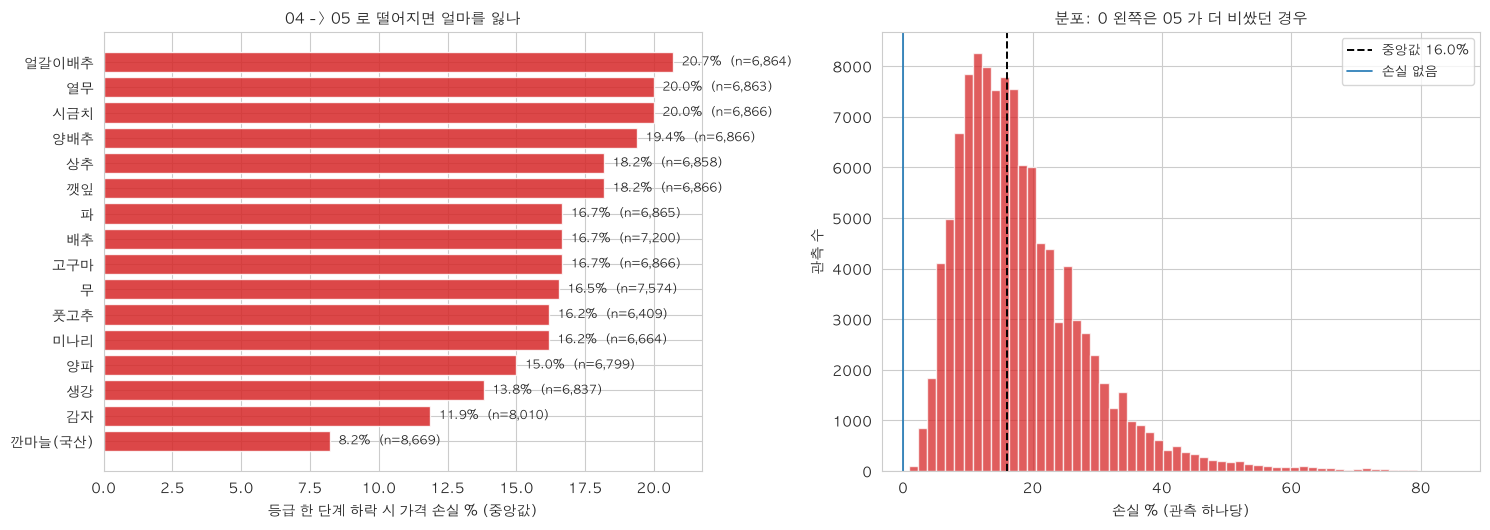

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

ax = axes[0]
s = 품목별.sort_values("손실_중앙")
ax.barh(s.index, s.손실_중앙, color="tab:red", alpha=0.85)
for i, (v, n) in enumerate(zip(s.손실_중앙, s.짝)):
    ax.text(v + 0.3, i, f"{v:.1f}%  (n={n:,})", va="center", fontsize=8.5)
ax.set_xlabel("등급 한 단계 하락 시 가격 손실 % (중앙값)")
ax.set_title("04 -> 05 로 떨어지면 얼마를 잃나", fontsize=11)

ax = axes[1]
ax.hist(w["손실 %"], bins=60, color="tab:red", alpha=0.75)
ax.axvline(전체중앙, color="black", ls="--", lw=1.4,
           label=f"중앙값 {전체중앙:.1f}%")
ax.axvline(0, color="tab:blue", lw=1.2, label="손실 없음")
ax.set_xlabel("손실 % (관측 하나당)")
ax.set_ylabel("관측 수")
ax.set_title("분포: 0 왼쪽은 05 가 더 비쌌던 경우", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 2. 계절과 품목에 따라 다른가

손실이 일정하면 한 숫자로 쓰면 되고, 계절에 따라 흔들리면 **여름에 더 위험**
같은 얘기가 됩니다. 17번에서 확신하는 날이 여름(6~7월)에 몰린다고 봤으니
특히 중요합니다.

,median,mean,size
월,,,
1,15.00,16.79,10013
2,14.93,16.78,9447
3,14.88,16.82,10379
4,16.13,18.15,10473
5,16.43,18.57,9817
6,17.14,19.04,10243
7,17.14,19.22,10895
8,14.89,17.59,8969
9,15.02,17.59,7863


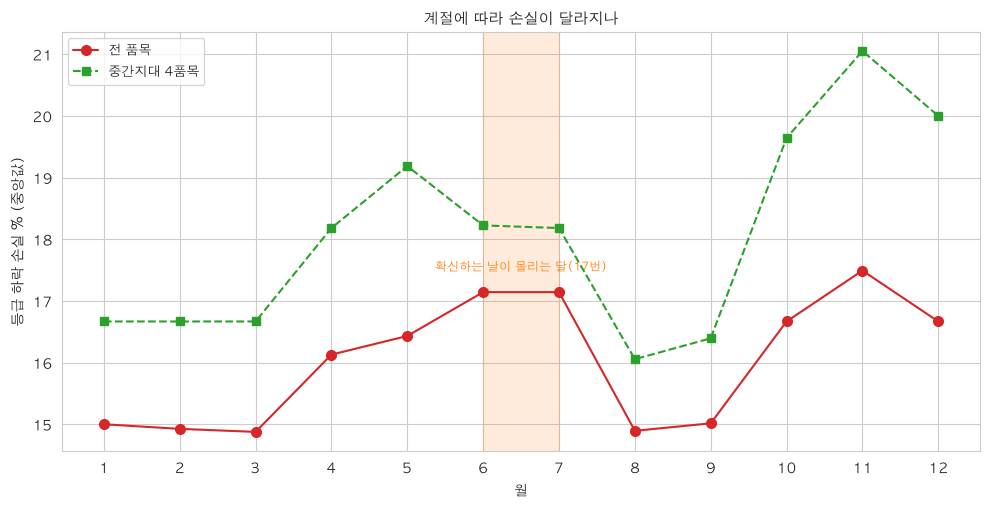

In [4]:
x = w.reset_index()
x["월"] = pd.to_datetime(x.date, errors="coerce").dt.month
x = x.dropna(subset=["월"])
월별 = x.groupby("월")["손실 %"].agg(["median", "mean", "size"])
display(월별.round(2))

중간지대 = ["상추", "얼갈이배추", "풋고추", "배추"]
mz = x[x.item.isin(중간지대)].groupby("월")["손실 %"].median()

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(월별.index, 월별["median"], "o-", ms=7, color="tab:red", label="전 품목")
if len(mz):
    ax.plot(mz.index, mz.values, "s--", ms=6, color="tab:green", label="중간지대 4품목")
ax.axvspan(6, 7, color="tab:orange", alpha=0.15)
ax.text(6.5, 월별["median"].max(), "확신하는 날이 몰리는 달(17번)", fontsize=8.5,
        color="tab:orange", ha="center")
ax.set_xticks(range(1, 13))
ax.set_xlabel("월")
ax.set_ylabel("등급 하락 손실 % (중앙값)")
ax.set_title("계절에 따라 손실이 달라지나", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. 손익분기 경계선

이제 조합을 그립니다. 손익분기는 이렇습니다.

```
창고비 c + 하락확률 p x 하락손실 g = 창고비 한도
```

`g` 는 1절에서 쟀고 한도는 15·19번 값입니다. **`c` 를 가로축, `p` 를 세로축**으로
놓으면 선 아래가 남는 영역입니다.

| 대상 | 창고비 한도 | 출처 |
|---|---|---|
| 중간지대 4품목 | **16.18%** | 15번, 확신도 0.20 |
| 실행 가능 11품목 | **13.25%** | 19번, 정체 품목 제외 후 |

In [5]:
한도 = {"중간지대 4품목": 16.18, "실행 가능 11품목": 13.25}
실행가능 = ["상추", "배추", "양배추", "무", "감자", "양파", "얼갈이배추",
           "풋고추", "고구마"]     # 마트 11품목 중 등급 수집이 된 것
g_mz = x[x.item.isin(중간지대)]["손실 %"].median()
g_ex = x[x.item.isin(실행가능)]["손실 %"].median()
g = {"중간지대 4품목": g_mz, "실행 가능 11품목": g_ex}
print("등급 하락 손실 g")
for k, v in g.items():
    print(f"  {k}: {v:.2f}%")

rows = []
for 이름, h in 한도.items():
    for c in (0, 1, 2, 3, 5, 8, 10):
        p_max = (h - c) / g[이름] * 100
        rows.append({"대상": 이름, "창고비 c %": c,
                     "견딜 수 있는 하락확률 p %": max(p_max, 0)})
경계 = pd.DataFrame(rows)
display(경계.pivot(index="창고비 c %", columns="대상",
                  values="견딜 수 있는 하락확률 p %").round(1))
print("표의 값보다 하락확률이 높으면 전략이 손해로 돌아섭니다.")
print("창고비가 한도를 넘으면 0 입니다(등급이 안 떨어져도 손해).")

등급 하락 손실 g
  중간지대 4품목: 18.18%
  실행 가능 11품목: 16.67%


대상,실행 가능 11품목,중간지대 4품목
창고비 c %,,
0,79.5,89.0
1,73.5,83.5
2,67.5,78.0
3,61.5,72.5
5,49.5,61.5
8,31.5,45.0
10,19.5,34.0


표의 값보다 하락확률이 높으면 전략이 손해로 돌아섭니다.
창고비가 한도를 넘으면 0 입니다(등급이 안 떨어져도 손해).


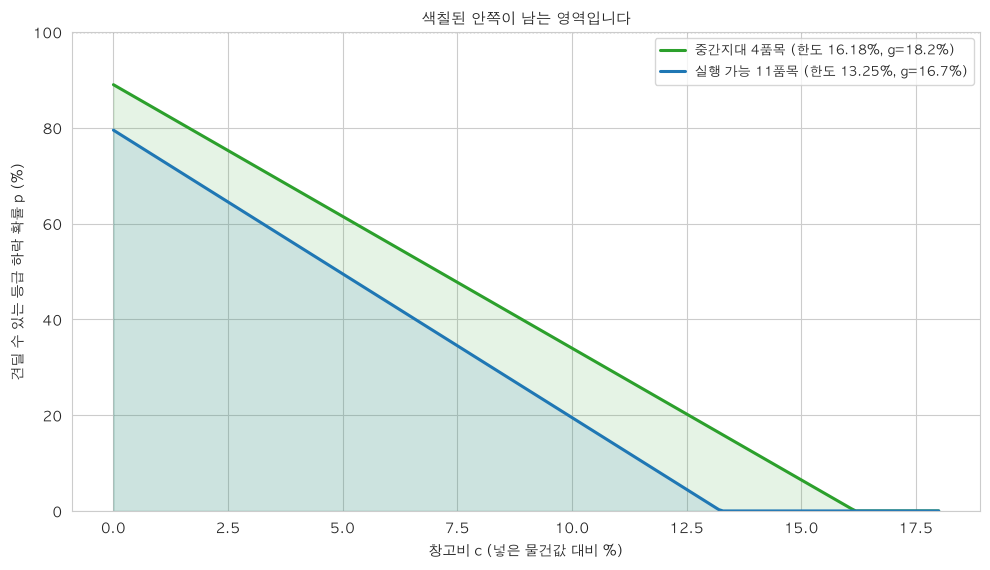

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.8))
cs = np.linspace(0, 18, 200)
for (이름, h), 색 in zip(한도.items(), ["tab:green", "tab:blue"]):
    p_max = np.clip((h - cs) / g[이름] * 100, 0, None)
    ax.plot(cs, p_max, lw=2.2, color=색, label=f"{이름} (한도 {h}%, g={g[이름]:.1f}%)")
    ax.fill_between(cs, 0, p_max, color=색, alpha=0.12)
ax.set_xlabel("창고비 c (넣은 물건값 대비 %)")
ax.set_ylabel("견딜 수 있는 등급 하락 확률 p (%)")
ax.set_title("색칠된 안쪽이 남는 영역입니다", fontsize=11)
ax.set_ylim(0, 100)
ax.legend(fontsize=9)
ax.axhline(100, color="gray", ls=":", lw=1)
plt.tight_layout()
plt.show()

## 4. 얼마나 위태로운가

경계선을 뒤집어 읽습니다: **"등급이 이만큼 떨어진다면 창고비는 얼마여야
하는가"** 입니다. 현장에 물어볼 질문을 좁히는 게 목적입니다.

In [7]:
rows = []
for 이름, h in 한도.items():
    for p in (0, 5, 10, 20, 30, 50, 100):
        c_max = h - p / 100 * g[이름]
        rows.append({"대상": 이름, "하락확률 p %": p,
                     "허용 창고비 c %": c_max})
역 = pd.DataFrame(rows)
display(역.pivot(index="하락확률 p %", columns="대상",
                values="허용 창고비 c %").round(2))
print("음수면 창고비가 0 원이어도 손해라는 뜻입니다.")

for 이름, h in 한도.items():
    p0 = h / g[이름] * 100
    print(f"\n{이름}: 창고비가 0 이어도 하락확률이 {p0:.0f}% 를 넘으면 손해입니다.")

대상,실행 가능 11품목,중간지대 4품목
하락확률 p %,,
0,13.25,16.18
5,12.42,15.27
10,11.58,14.36
20,9.92,12.54
30,8.25,10.73
50,4.92,7.09
100,-3.42,-2.00


음수면 창고비가 0 원이어도 손해라는 뜻입니다.

중간지대 4품목: 창고비가 0 이어도 하락확률이 89% 를 넘으면 손해입니다.

실행 가능 11품목: 창고비가 0 이어도 하락확률이 80% 를 넘으면 손해입니다.


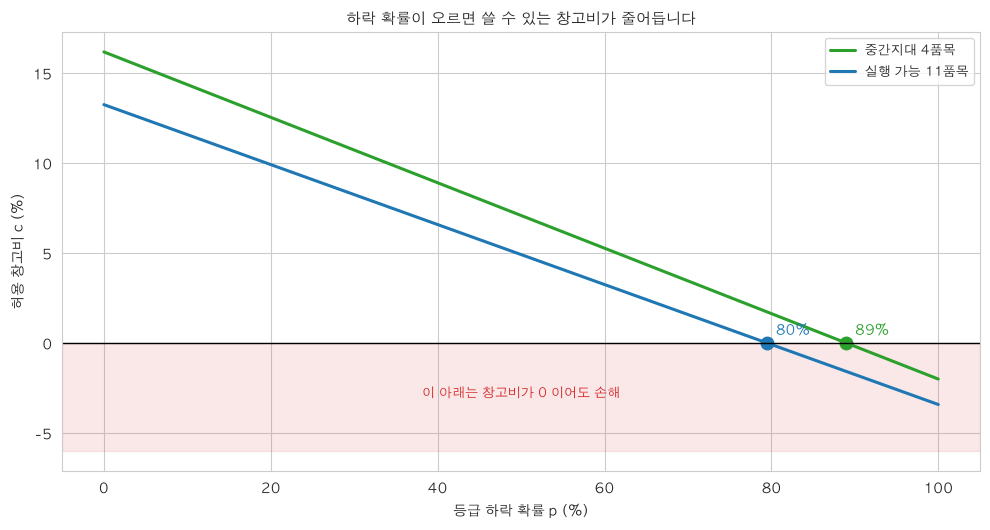

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.4))
ps = np.linspace(0, 100, 200)
for (이름, h), 색 in zip(한도.items(), ["tab:green", "tab:blue"]):
    c_max = h - ps / 100 * g[이름]
    ax.plot(ps, c_max, lw=2.2, color=색, label=f"{이름}")
    p0 = h / g[이름] * 100
    ax.plot([p0], [0], "o", ms=9, color=색)
    ax.annotate(f"{p0:.0f}%", (p0, 0), fontsize=10, color=색,
                xytext=(6, 6), textcoords="offset points")
ax.axhline(0, color="black", lw=1)
ax.axhspan(-6, 0, color="tab:red", alpha=0.10)
ax.text(50, -3, "이 아래는 창고비가 0 이어도 손해", fontsize=9, color="tab:red",
        ha="center")
ax.set_xlabel("등급 하락 확률 p (%)")
ax.set_ylabel("허용 창고비 c (%)")
ax.set_title("하락 확률이 오르면 쓸 수 있는 창고비가 줄어듭니다", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. 정리

### 한 줄 요약

**등급 하락 손실은 크지만(중앙값 16.00%), 전략은 생각보다 강건합니다.**
창고비가 0 이라면 **하락 확률 80~89% 까지** 견딥니다. 등급이 조금 떨어지는
정도로는 안 무너집니다.

### 측정된 것: 등급 하락 손실 g

**113,076 쌍**을 같은 날·같은 시장·같은 규격으로 짝지어 쟀습니다.

| 품목 | 손실 중앙값 | 짝 | 05 가 싼 비율 |
|---|---|---|---|
| 얼갈이배추 | **20.70%** | 6,864 | 100% |
| 시금치 · 열무 | 20.00% | 6,866 · 6,863 | 100% |
| 양배추 | 19.38% | 6,866 | 100% |
| 깻잎 · 상추 | 18.18% | 6,866 · 6,858 | 100% |
| 고구마 · 배추 · 파 | 16.67% | 6,866 · 7,200 · 6,865 | 100% |
| 무 · 풋고추 · 미나리 | 16.2~16.5% | 6,409~7,574 | 100% |
| 양파 | 15.00% | 6,799 | 100% |
| 생강 | 13.81% | 6,837 | 100% |
| 감자 | 11.87% | 8,010 | 100% |
| 깐마늘(국산) | **8.23%** | 8,669 | 100% |
| **전체** | **16.00%** | 113,076 | **100%** |

**예외가 한 건도 없습니다.** 11만 쌍 전부에서 05 가 04 보다 쌌습니다. 등급은
가격에 확실하게 반영됩니다.

**엽채류가 가장 많이 잃고(20% 안팎) 저장성 품목이 적게 잃습니다**(감자 11.87%,
깐마늘 8.23%). 14번의 저장성 축이 여기서도 나타납니다: 저장이 되는 품목은
품질 저하에 따른 가격 차이도 완만합니다. **관찰이지 증명은 아닙니다.**

### 계절: 하필 여름이 나쁩니다

| 월 | 손실 중앙값 |
|---|---|
| 11월 | **17.49%** |
| 6·7월 | **17.14%** |
| 12월 · 10월 | 16.67% |
| 2·3월 | **14.9%** |

**17번에서 확신하는 날이 6~7월에 몰린다고 봤는데, 그때가 손실도 가장 큰
축입니다.** 많이 행동하는 달에 위험도 크다는 뜻이라 불리한 조합입니다.
다만 폭이 14.9~17.5% 로 좁아 결론을 뒤집을 크기는 아닙니다.

### 경계선: 얼마까지 견디나

`창고비 c + 하락확률 p × 손실 g = 창고비 한도`

| 창고비 c | 중간지대 4품목 | 실행 가능 11품목 |
|---|---|---|
| **0%** | **89.0%** | **79.5%** |
| 1% | 83.5% | 73.5% |
| 3% | 72.5% | 61.5% |
| 5% | 61.5% | 49.5% |
| 8% | 45.0% | 31.5% |
| 10% | 34.0% | 19.5% |

표의 값보다 하락 확률이 높으면 손해로 돌아섭니다.

뒤집어 읽으면 이렇습니다.

| 하락확률 p | 중간지대 허용 창고비 | 실행가능 허용 창고비 |
|---|---|---|
| 0% | 16.18% | 13.25% |
| 10% | 14.36% | 11.58% |
| 30% | 10.73% | 8.25% |
| 50% | 7.09% | 4.92% |
| **100%** | **-2.00%** | **-3.42%** |

**모든 물건이 한 등급씩 떨어진다면(p=100%) 창고비가 0 원이어도 손해입니다.**
손실 g(16~18%)가 한도(13~16%)보다 크기 때문입니다. 그 지점이 중간지대 89%,
실행가능 80% 입니다.

### 강건성 판정

**등급 하락은 생각만큼 치명적이지 않습니다.** 창고비가 0 이라는 비현실적
가정에서는 89% 까지, 창고비 5% 라면 61.5% 까지 견딥니다. **7거래일 저장에
전체 물량의 60% 가 등급을 잃는 상황**은 상식적으로 보기 어렵습니다.

**결정적인 건 여전히 창고비입니다.** 창고비 10% 면 견디는 확률이 34% 로
떨어지고, 13.25% 를 넘으면 등급이 하나도 안 떨어져도 손해입니다(19번).

### 한계

- **`p` 는 못 구합니다.** 같은 물건을 추적한 데이터가 아니라, 매일 나온 04 와
  05 를 따로 관측한 것뿐입니다. **이 문서의 경계선은 가정이지 예측이 아닙니다.**
- **04→05 한 단계만 잽니다.** 두 단계(05 아래)가 있는지, 아예 폐기되는 비율이
  얼마인지는 모릅니다. **감모(무게 감소)도 여전히 안 들어갔습니다.**
- **`g` 를 중앙값으로 씁니다.** 풋고추는 표준편차가 19.95 로 유독 큽니다
  (평균 25.22 vs 중앙값 16.19). 그 품목만은 중앙값이 대표값이 아닙니다.
- **04 가 상품인지 확인 안 했습니다.** `p_productrankcode` 의 04·05 가 무엇을
  뜻하는지는 KAMIS 코드표를 봐야 합니다. 지금은 "한 단계 차이"로만 다룹니다.
- **한도(16.18%·13.25%)는 15·19번 값**이라, 그 계산의 가정(확신도 0.20, 19품목
  학습)을 그대로 물려받습니다.

### 다음

1. **현장에 물을 질문이 둘로 좁혀졌습니다.**
   - 7거래일 저온저장 비용이 물건값의 몇 % 인가
   - 7거래일 저장 시 등급이 떨어지는 비율이 몇 % 인가
   둘 다 있으면 이 표에서 바로 남는지 아닌지가 나옵니다.
2. **감모는 아직 안 잡혔습니다.** 등급과 별개로 무게가 줄어드는 부분인데,
   이 데이터에는 없습니다.
3. **05 등급으로 모델을 다시 돌릴 수도 있습니다.** 다만 등급이 다르다고 예측
   가능성이 다를 이유가 뚜렷하지 않아, 우선순위는 낮습니다.